In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp

import warnings
warnings.filterwarnings('ignore')

In [36]:
df = pd.read_csv('climate_change_impact_on_agriculture_2024.csv')
df.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [37]:
print(f'The Number of rows in our dataset are: {df.shape[0]}\nThe Number of columns are: {df.shape[1]}')

The Number of rows in our dataset are: 10000
The Number of columns are: 15


In [65]:
print(f'Columns available in our Datasets are:\n\n {df.columns}')

Columns available in our Datasets are:

 Index(['Year', 'Country', 'Region', 'Crop_Type', 'Average_Temperature_C',
       'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Crop_Yield_MT_per_HA',
       'Extreme_Weather_Events', 'Irrigation_Access_%',
       'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA',
       'Soil_Health_Index', 'Adaptation_Strategies',
       'Economic_Impact_Million_USD'],
      dtype='object')


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

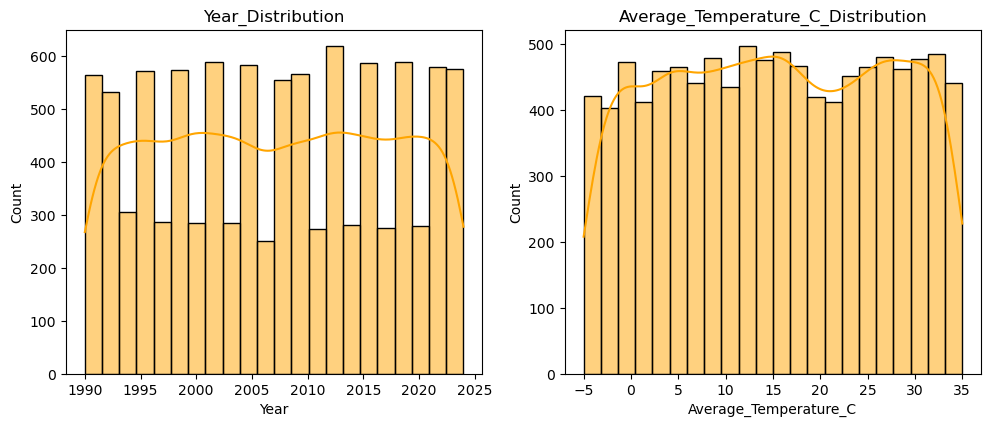

In [40]:
# Filter out non-object (numerical) columns
num_columns = [col for col in df.columns if df[col].dtype!= 'O']

# Create subplots grid based on the number of numerical columns
num_plots = len(num_columns)
rows = (num_plots + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))

# Flatten the axes array to make it easier to loop through
axes = axes.flatten()

# Loop through each numerical column and plot its histogram in a subplot
for i, col in enumerate (num_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='orange')
    axes[i].set_title(f'{col}_Distribution')

# Delete any extra subplots if we have less than 3*rows plots
for j in range(1 + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

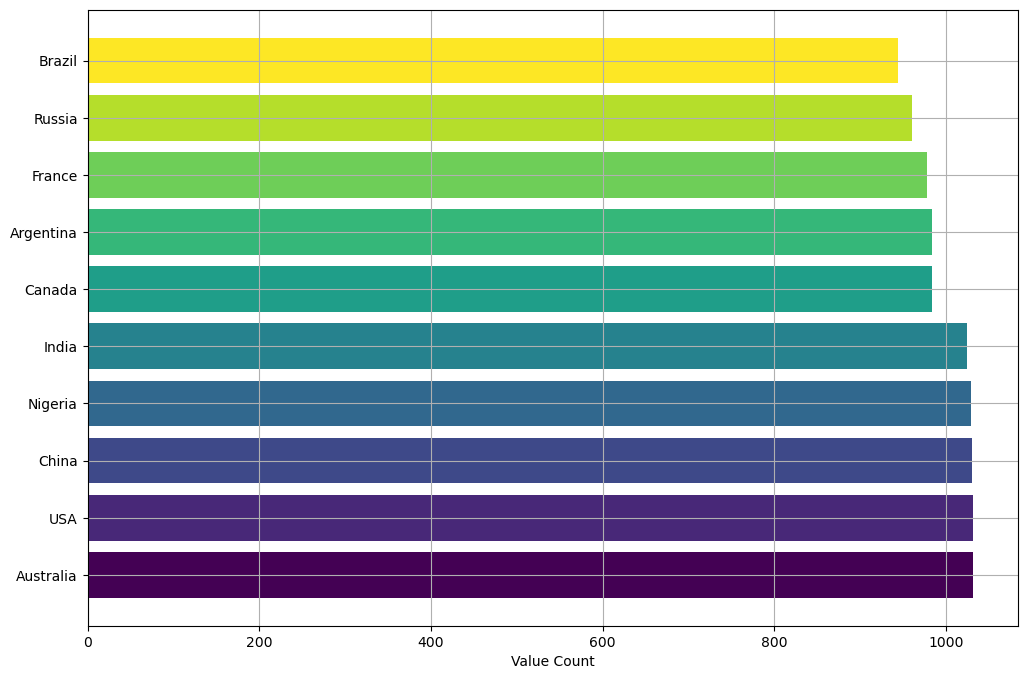

In [41]:
c_counts = df['Country'].value_counts()
plt.figure(figsize=(12,8))
colors = cm.viridis(np.linspace(0, 1, len(c_counts.values)))
plt.barh(c_counts.index,c_counts.values, color=colors)
plt.xlabel('Value Count')
plt.grid()
plt.show()

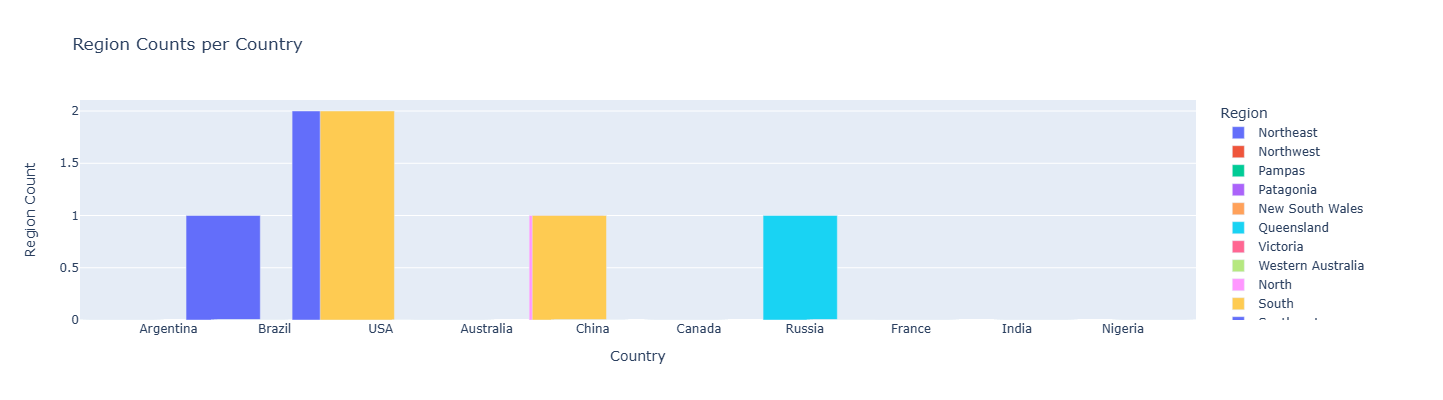

In [74]:
# Grouping the data by 'Country' and 'Region', then getting the value counts
grouped_data = df.groupby(['Country', 'Region']).size().reset_index(name='Count')

# Plotting with px.bar
fig = px.bar(grouped_data,
            x='Country',
            y='Count',
            color='Region',
            title="Region Counts per Country",
            labels={'Count': 'Region Count'},
            barmode='group')
# Showing the plot
fig.update_layout(
    width=1000,
    height=400, 
    bargap=0.0,
    bargroupgap=0.3)
# Increase individual bar thickness
fig.update_traces(width=0.7)
fig.show()

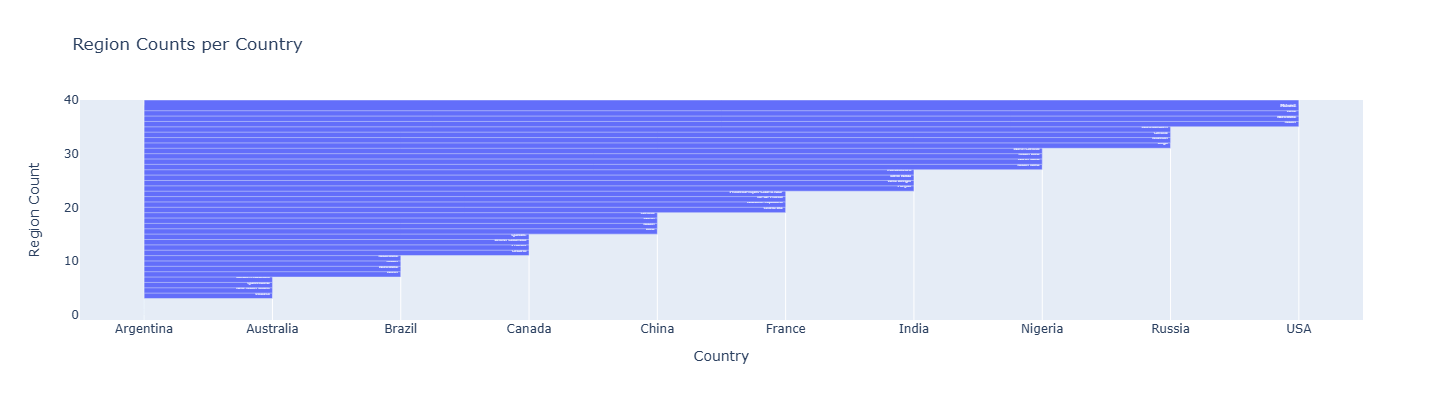

In [77]:
# Sample data (adjust according to your data)
grouped_data = df.groupby('Country')['Region'].value_counts().reset_index(name='Count')

# Create figure
fig = go.Figure()

# Add bar trace
fig.add_trace(go.Bar(
    x=grouped_data['Country'],
    y=grouped_data['Count'],
    name='Region Count',
    text=grouped_data['Region'],
    width=2.    
))
# Update layout for plot size and title
fig.update_layout(
    title="Region Counts per Country",
    xaxis_title="Country",
    yaxis_title="Region Count",
    width=900,  # Width of the figure
    height=400,
)
# Show the plot
fig.show()

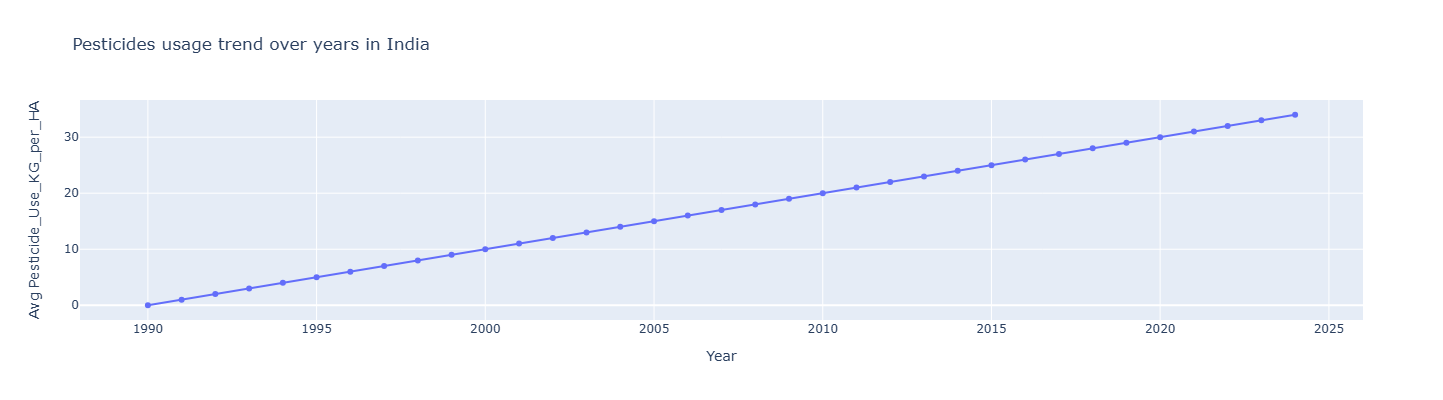

In [80]:
df1 = df[df['Country'] == 'India']
pp = df1.groupby('Year')['Pesticide_Use_KG_per_HA'].mean().reset_index(name='Avg Pesticide_Use_KG_per_HA')

fig = px.line(pp,
              x='Year',
              y='Avg Pesticide_Use_KG_per_HA',
              title="Pesticides usage trend over years in India",
              markers=True)
fig.update_layout(
    width=800,
    height=400)
fig.show()

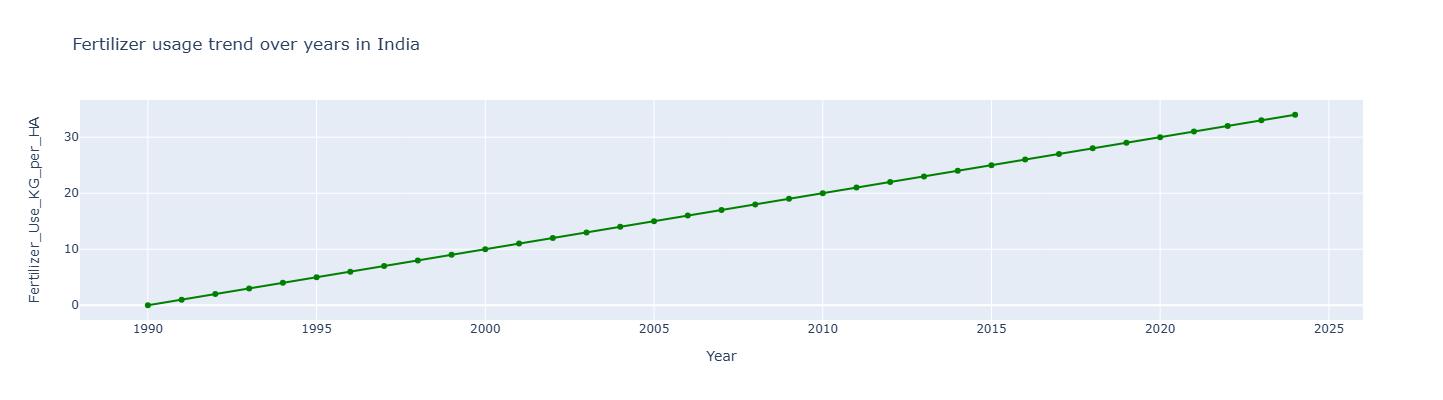

In [89]:
pp = df1.groupby('Year')['Fertilizer_Use_KG_per_HA'].mean().reset_index(name='Fertilizer_Use_KG_per_HA')

fig = px.line(pp,
             x='Year',
             y='Fertilizer_Use_KG_per_HA',
             title="Fertilizer usage trend over years in India",
             color_discrete_sequence=['green'],
             markers=True)
fig.update_layout(
    width=800,
    height=400)
fig.show()

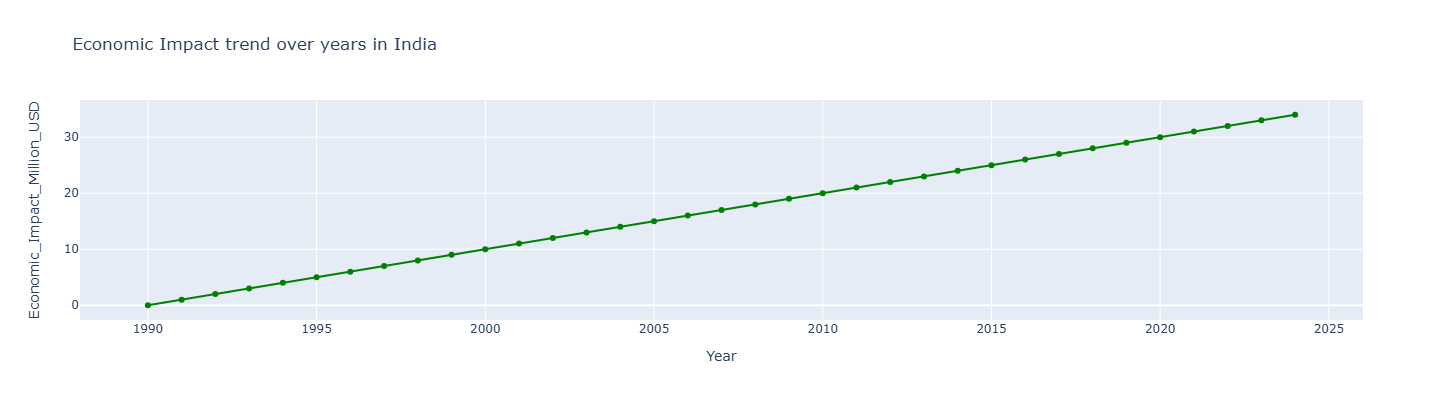

In [84]:
pp = df1.groupby('Year')['Economic_Impact_Million_USD'].mean().reset_index(name='Economic_Impact_Million_USD')

fig = px.line(pp,
             x='Year',
             y='Economic_Impact_Million_USD',
             title="Economic Impact trend over years in India",
             color_discrete_sequence=['green'],
             markers=True)
fig.update_layout(
    width=800,
    height=400)
fig.show()

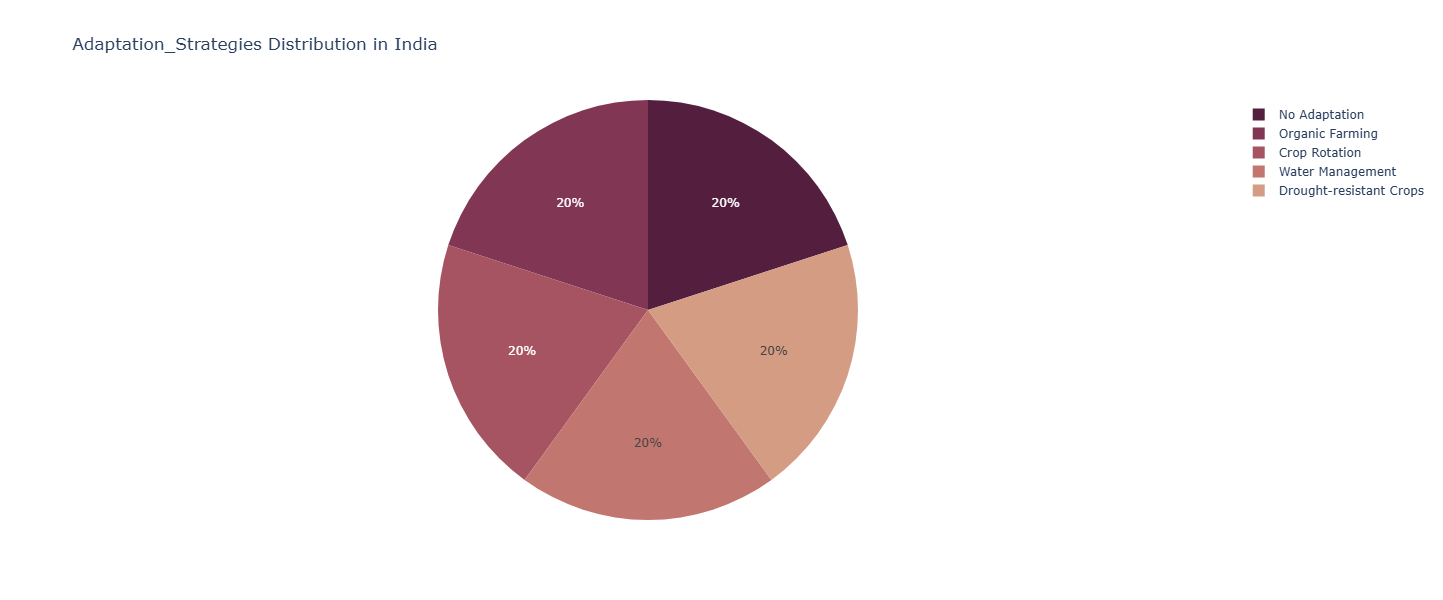

In [47]:
df2 = df1['Adaptation_Strategies'].value_counts().reset_index(name='Counts')

fig = px.pie(df2,
            names='Adaptation_Strategies',
            values='Counts',
            title='Adaptation_Strategies Distribution in India',
            color_discrete_sequence=px.colors.sequential.Brwnyl_r)
# Increase the figure size
fig.update_layout(
    width=900,    # Width in pixels
    height=600    # Height in pixels
)
# Show the figure
fig.show()

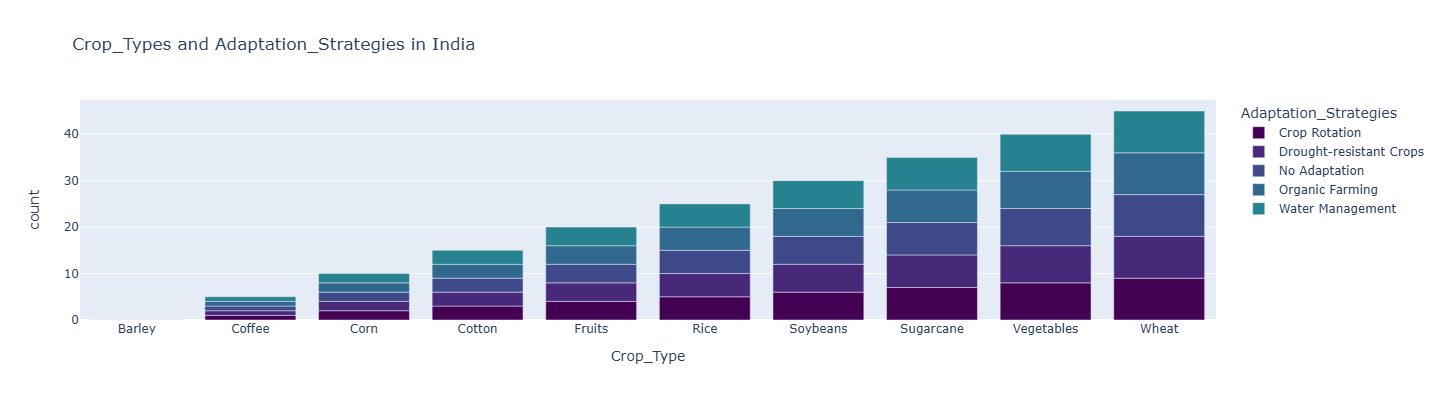

In [48]:
df2 = df1.groupby(['Crop_Type', 'Adaptation_Strategies']).size().reset_index(name='count')

fig = px.bar(df2,
            x='Crop_Type',
            y='count',
            title='Crop_Types and Adaptation_Strategies in India',
            color='Adaptation_Strategies',
             color_discrete_sequence=px.colors.sequential.Viridis)
fig.update_layout(
width=800,
height=400)
fig.show()

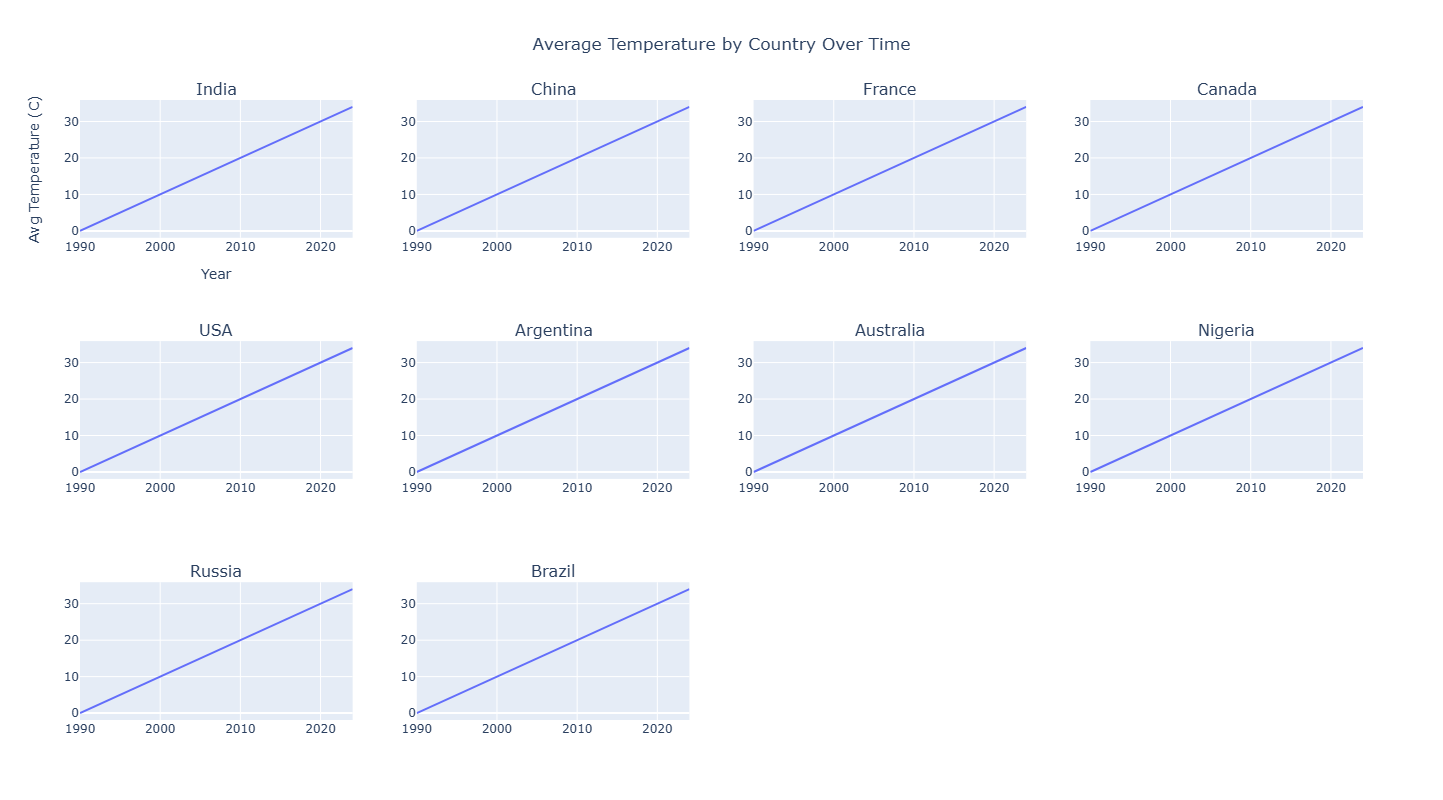

In [49]:
# Trend Analysis Over Time
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Get the list of unique countries
countries = df['Country'].unique()

# Create subplots
fig = sp.make_subplots(rows=3, cols=4, shared_xaxes=False,
                      subplot_titles=countries)

# Loop through each country and add to the subplot
for i, country in enumerate(countries):

    country_data = df[df['Country'] == country]
    yearly_avg_temp = country_data.groupby('Year')['Average_Temperature_C'].mean().reset_index()

    # Determine row and column for the subplot
    row = (i // 4) + 1
    col = (i % 4) + 1

    # Create line plot for each country and add to the subplot
    fig.add_trace(
        px.line(yearly_avg_temp,
               x='Year',
               y='Average_Temperature_C',
               title=f'Avg Temp in: {country}').data[0],
        row=row, col=col)
# Update layout for the subplots
fig.update_layout(
    height=800, width=1200, 
    title_text="Average Temperature by Country Over Time\n", 
    showlegend=False,
    xaxis_title='Year',
    yaxis_title='Avg Temperature (C)',
    title_x=0.5
)
# Show the figure
fig.show()    

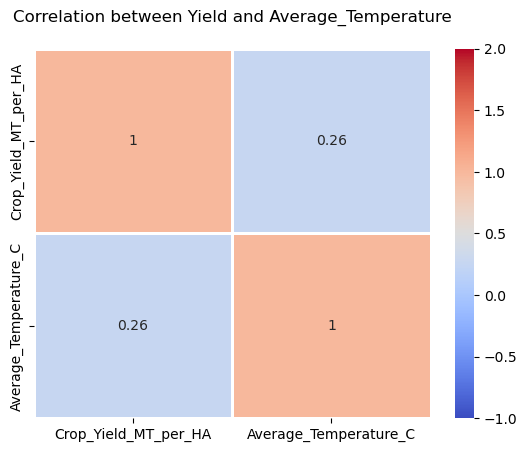

In [50]:
tempy = df[['Crop_Yield_MT_per_HA','Average_Temperature_C']].corr()
sns.heatmap(tempy, annot=True, cmap='coolwarm', linewidth=0.8, vmin=-1, vmax=2)
plt.title('Correlation between Yield and Average_Temperature\n')
plt.show()

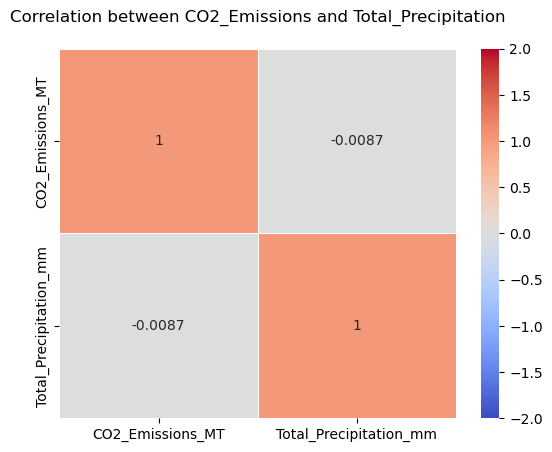

In [51]:
Prec_Co2_corr = df[['CO2_Emissions_MT','Total_Precipitation_mm']].corr()
sns.heatmap(Prec_Co2_corr, annot=True, cmap='coolwarm', linewidth=0.5, vmin=-2, vmax=2)
plt.title('Correlation between CO2_Emissions and Total_Precipitation\n')
plt.show()

In [52]:
df.Crop_Type.value_counts()

Crop_Type
Wheat         1047
Cotton        1044
Vegetables    1036
Corn          1022
Rice          1022
Sugarcane      995
Fruits         979
Soybeans       958
Barley         952
Coffee         945
Name: count, dtype: int64

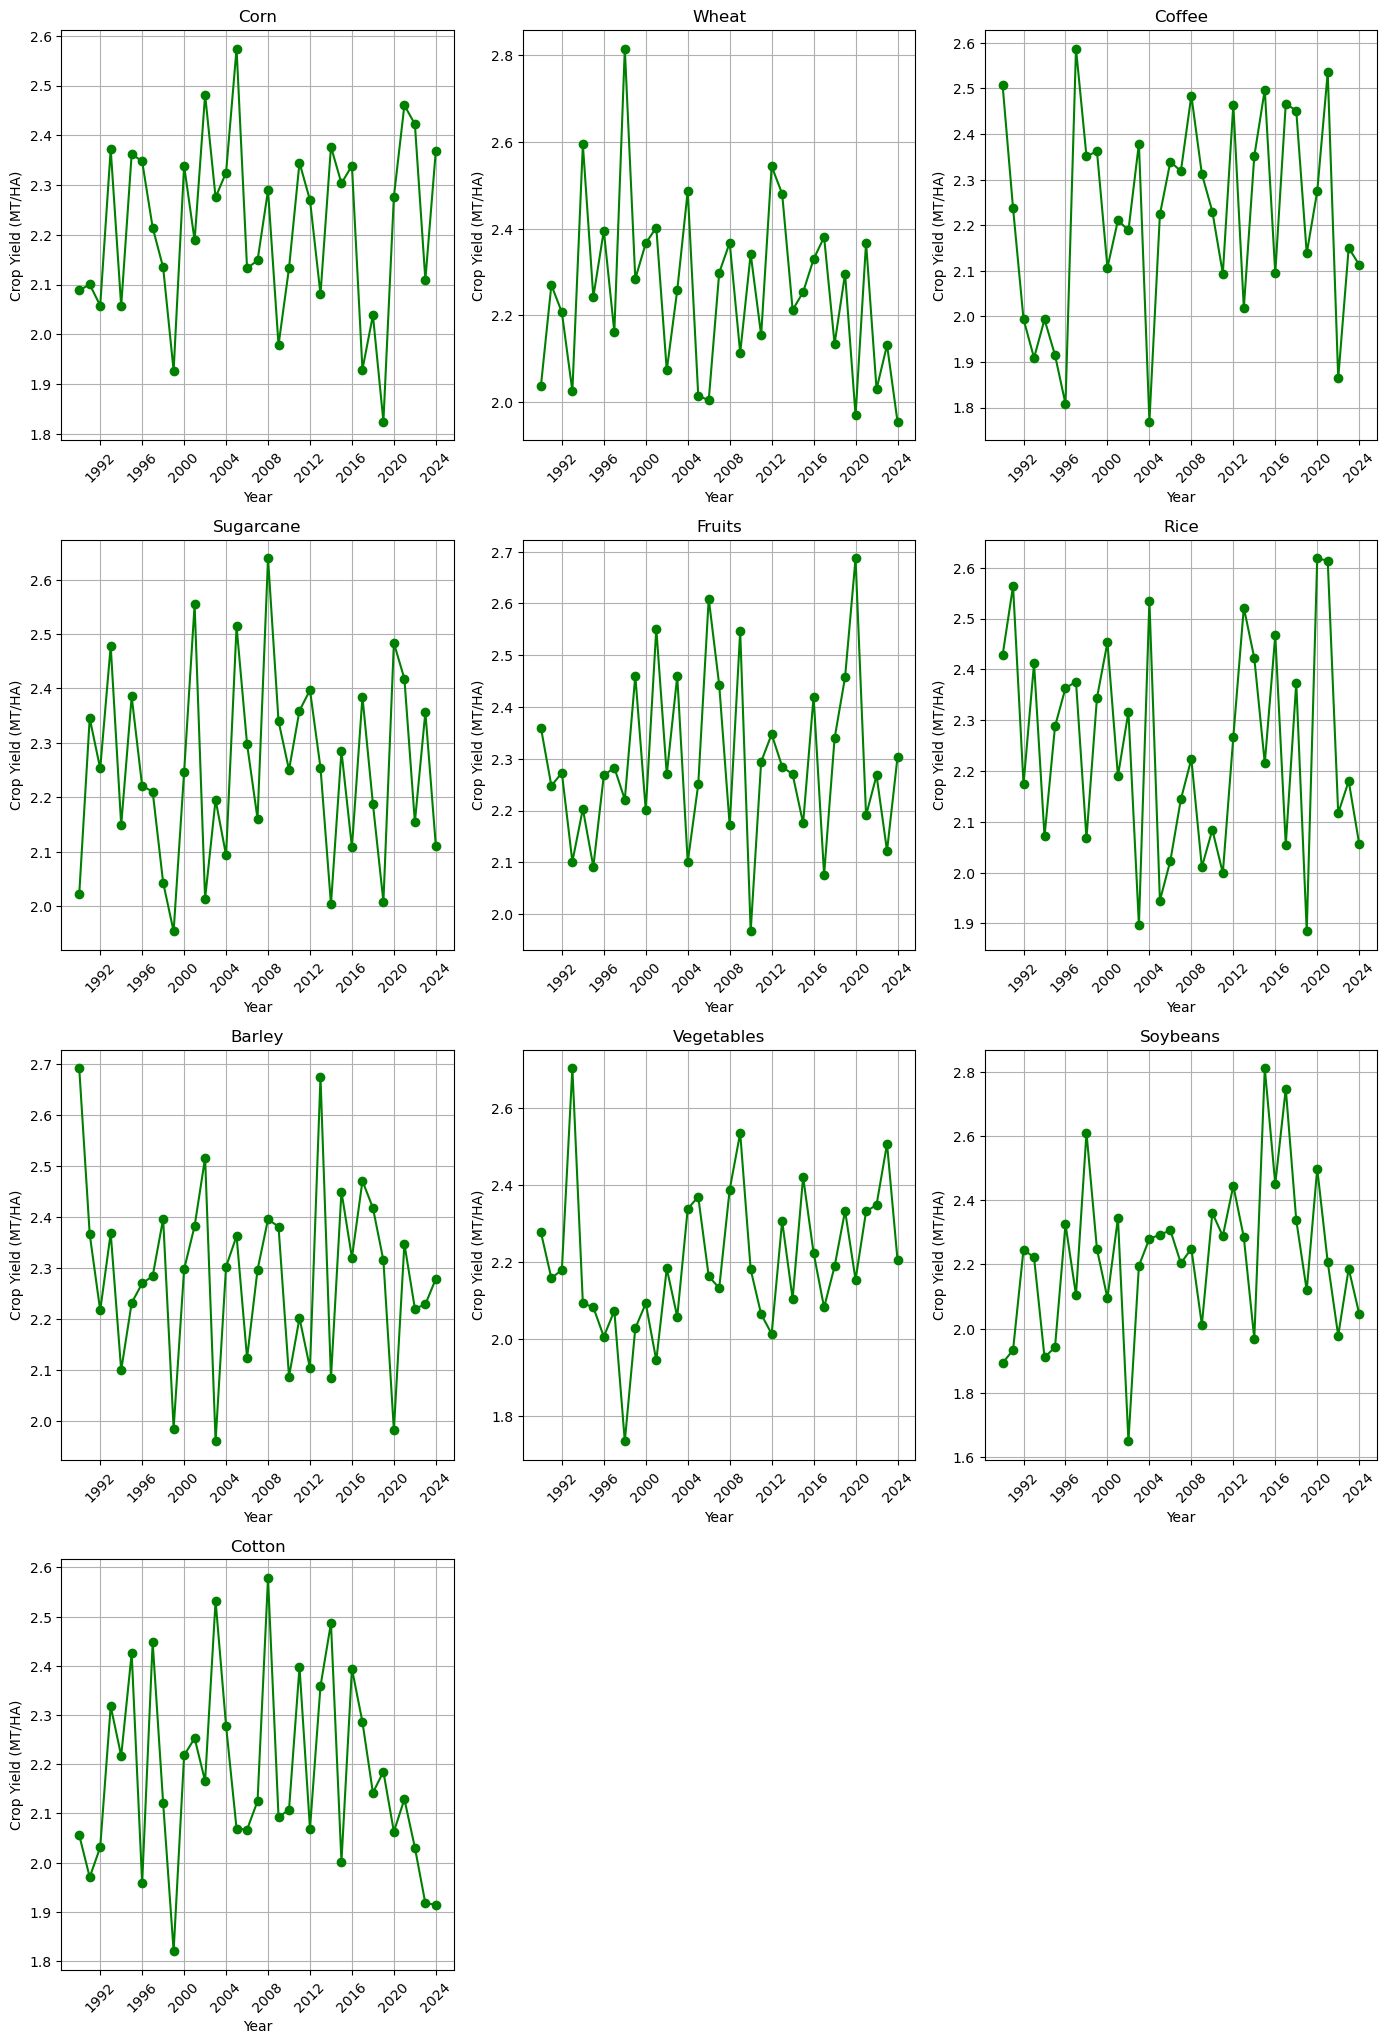

In [96]:
# Yield Trend of Each Crop Over Years

crops = df['Crop_Type'].unique()
n_crops = len(crops)

# Create enough subplot positions
fig, axes = plt.subplots(
    nrows=int(np.ceil(n_crops / 2)),
    ncols=3,
    figsize=(14, 5 * int(np.ceil(n_crops / 2)))
)

# Make axes a 1D array
axes = np.array(axes).flatten()

for i, crop in enumerate(crops):

    # Filter data for the current crop
    crop_df = df[df['Crop_Type'] == crop]

    # Calculate average yield for each year
    yield_df = (
        crop_df.groupby('Year')['Crop_Yield_MT_per_HA']
        .mean()
        .reset_index()
    )

    # Plot yield trend
    axes[i].plot(
        yield_df['Year'],
        yield_df['Crop_Yield_MT_per_HA'],
        color='green',
        marker='o'
    )

    axes[i].set_title(f'{crop}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Crop Yield (MT/HA)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True)

# Remove unused subplot spaces
for j in range(n_crops, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

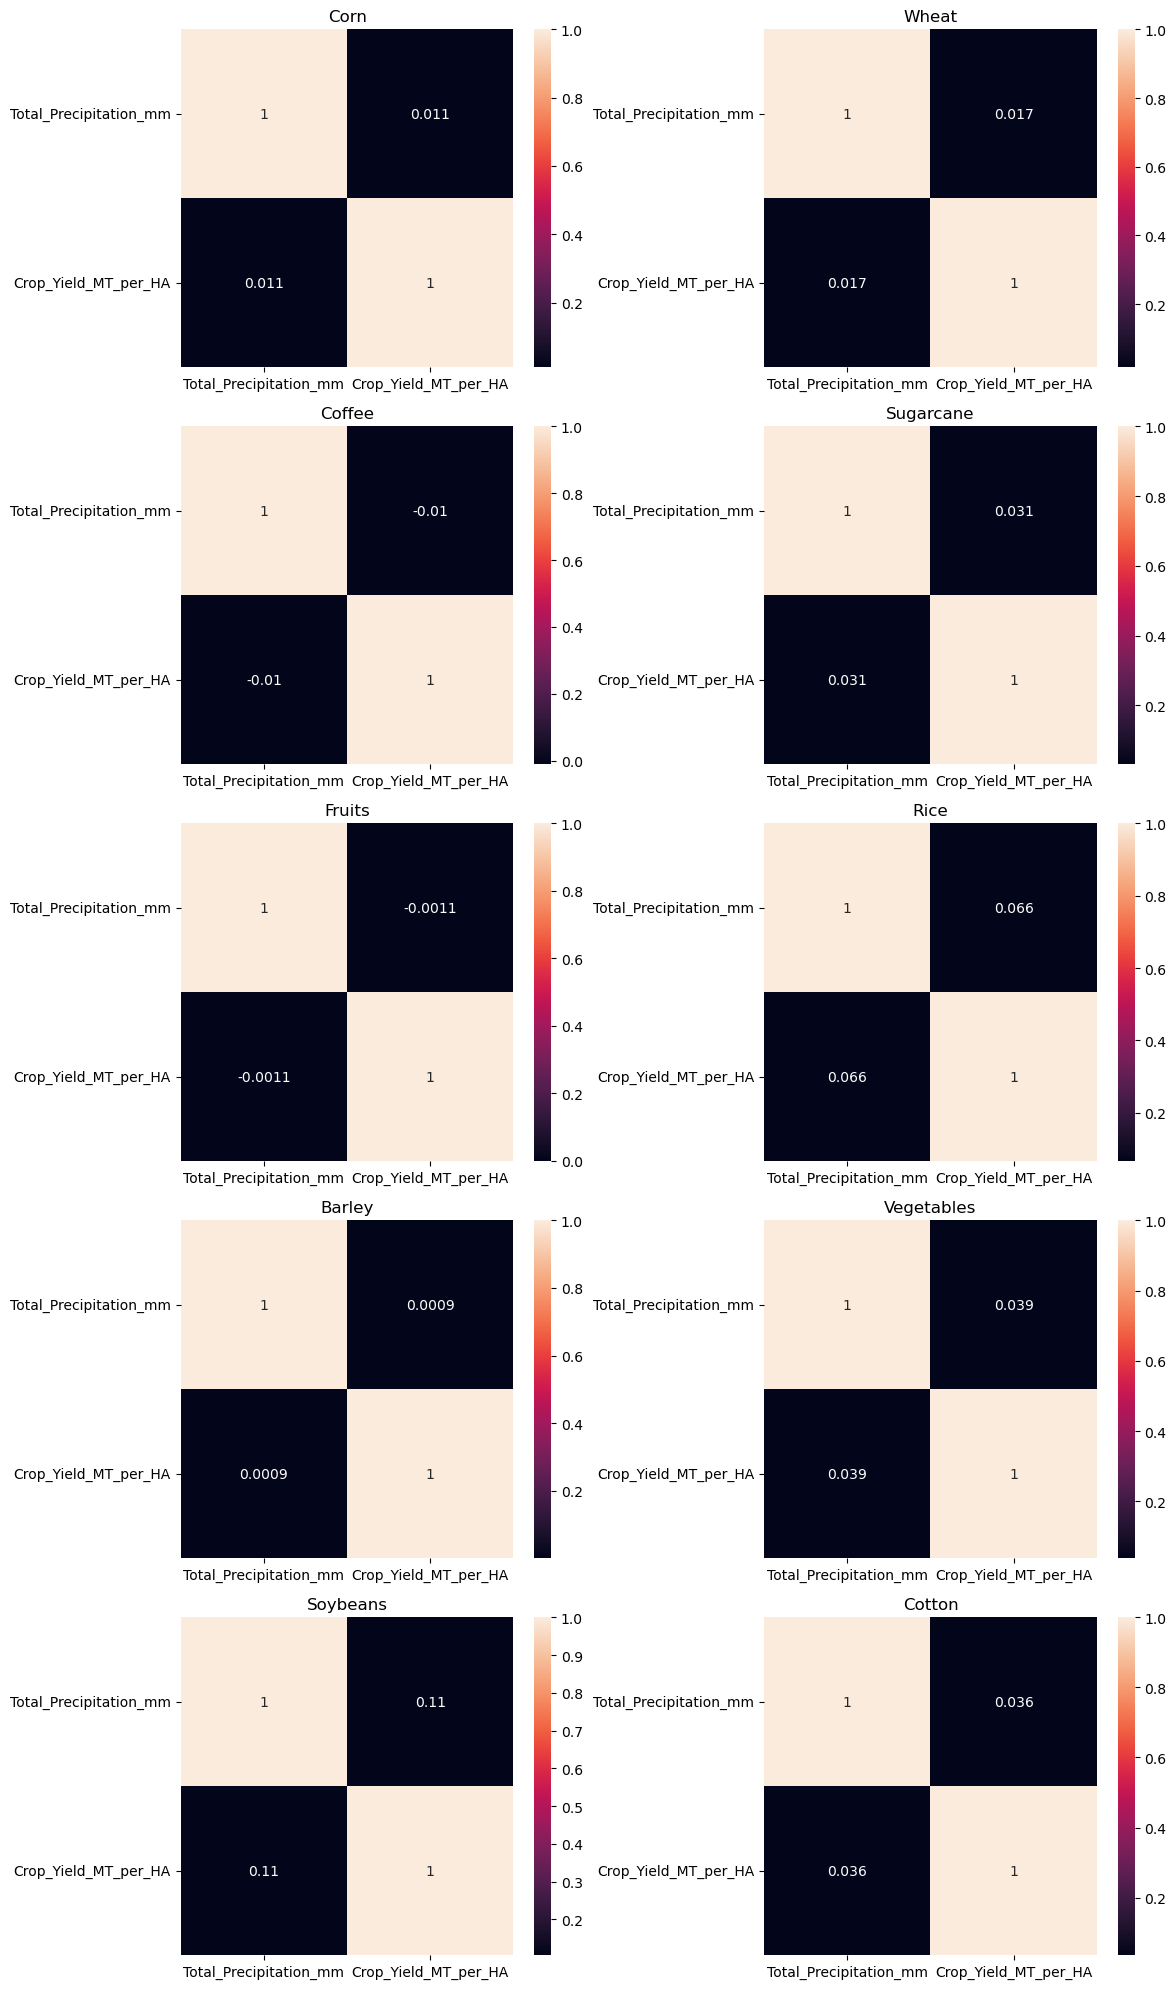

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

crops = df['Crop_Type'].unique()
n_crops = len(crops)

# Create enough rows for 2 columns
n_rows = int(np.ceil(n_crops / 2))

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(12, 4 * n_rows)
)

# Convert axes into a 1D array
axes = np.array(axes).flatten()

# Create heatmap for each crop
for i, crop in enumerate(crops):

    crops_df = df[df['Crop_Type'] == crop]

    sns.heatmap(
        crops_df[
            ['Total_Precipitation_mm', 'Crop_Yield_MT_per_HA']
        ].corr(),
        annot=True,
        ax=axes[i]
    )

    axes[i].set_title(crop)

# Remove unused subplot spaces
for j in range(n_crops, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [98]:
df['Adaptation_Strategies'].value_counts()

Adaptation_Strategies
Water Management           2049
No Adaptation              2024
Drought-resistant Crops    1995
Organic Farming            1975
Crop Rotation              1957
Name: count, dtype: int64

<Axes: >

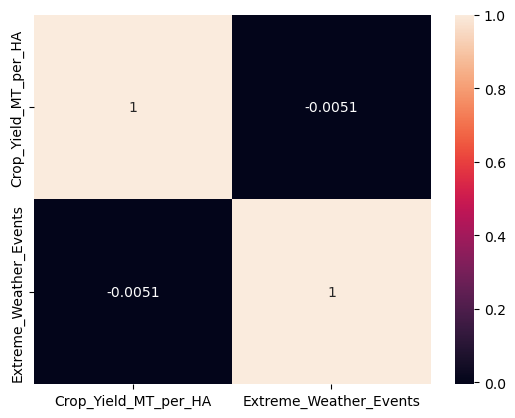

In [99]:
org_farm = df[df['Adaptation_Strategies'] == 'Organic Farming']
sns.heatmap(df[['Crop_Yield_MT_per_HA','Extreme_Weather_Events']].corr(), annot=True)

<Axes: >

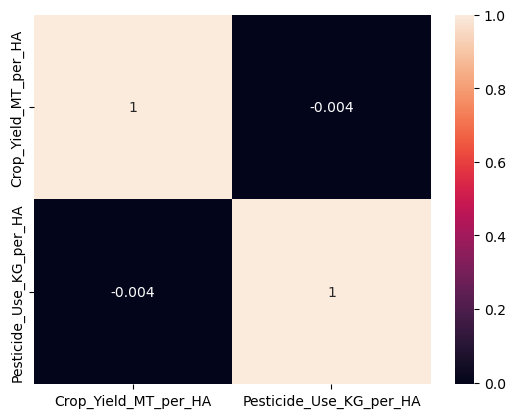

In [56]:
sns.heatmap(df[['Crop_Yield_MT_per_HA','Pesticide_Use_KG_per_HA']].corr(), annot=True)

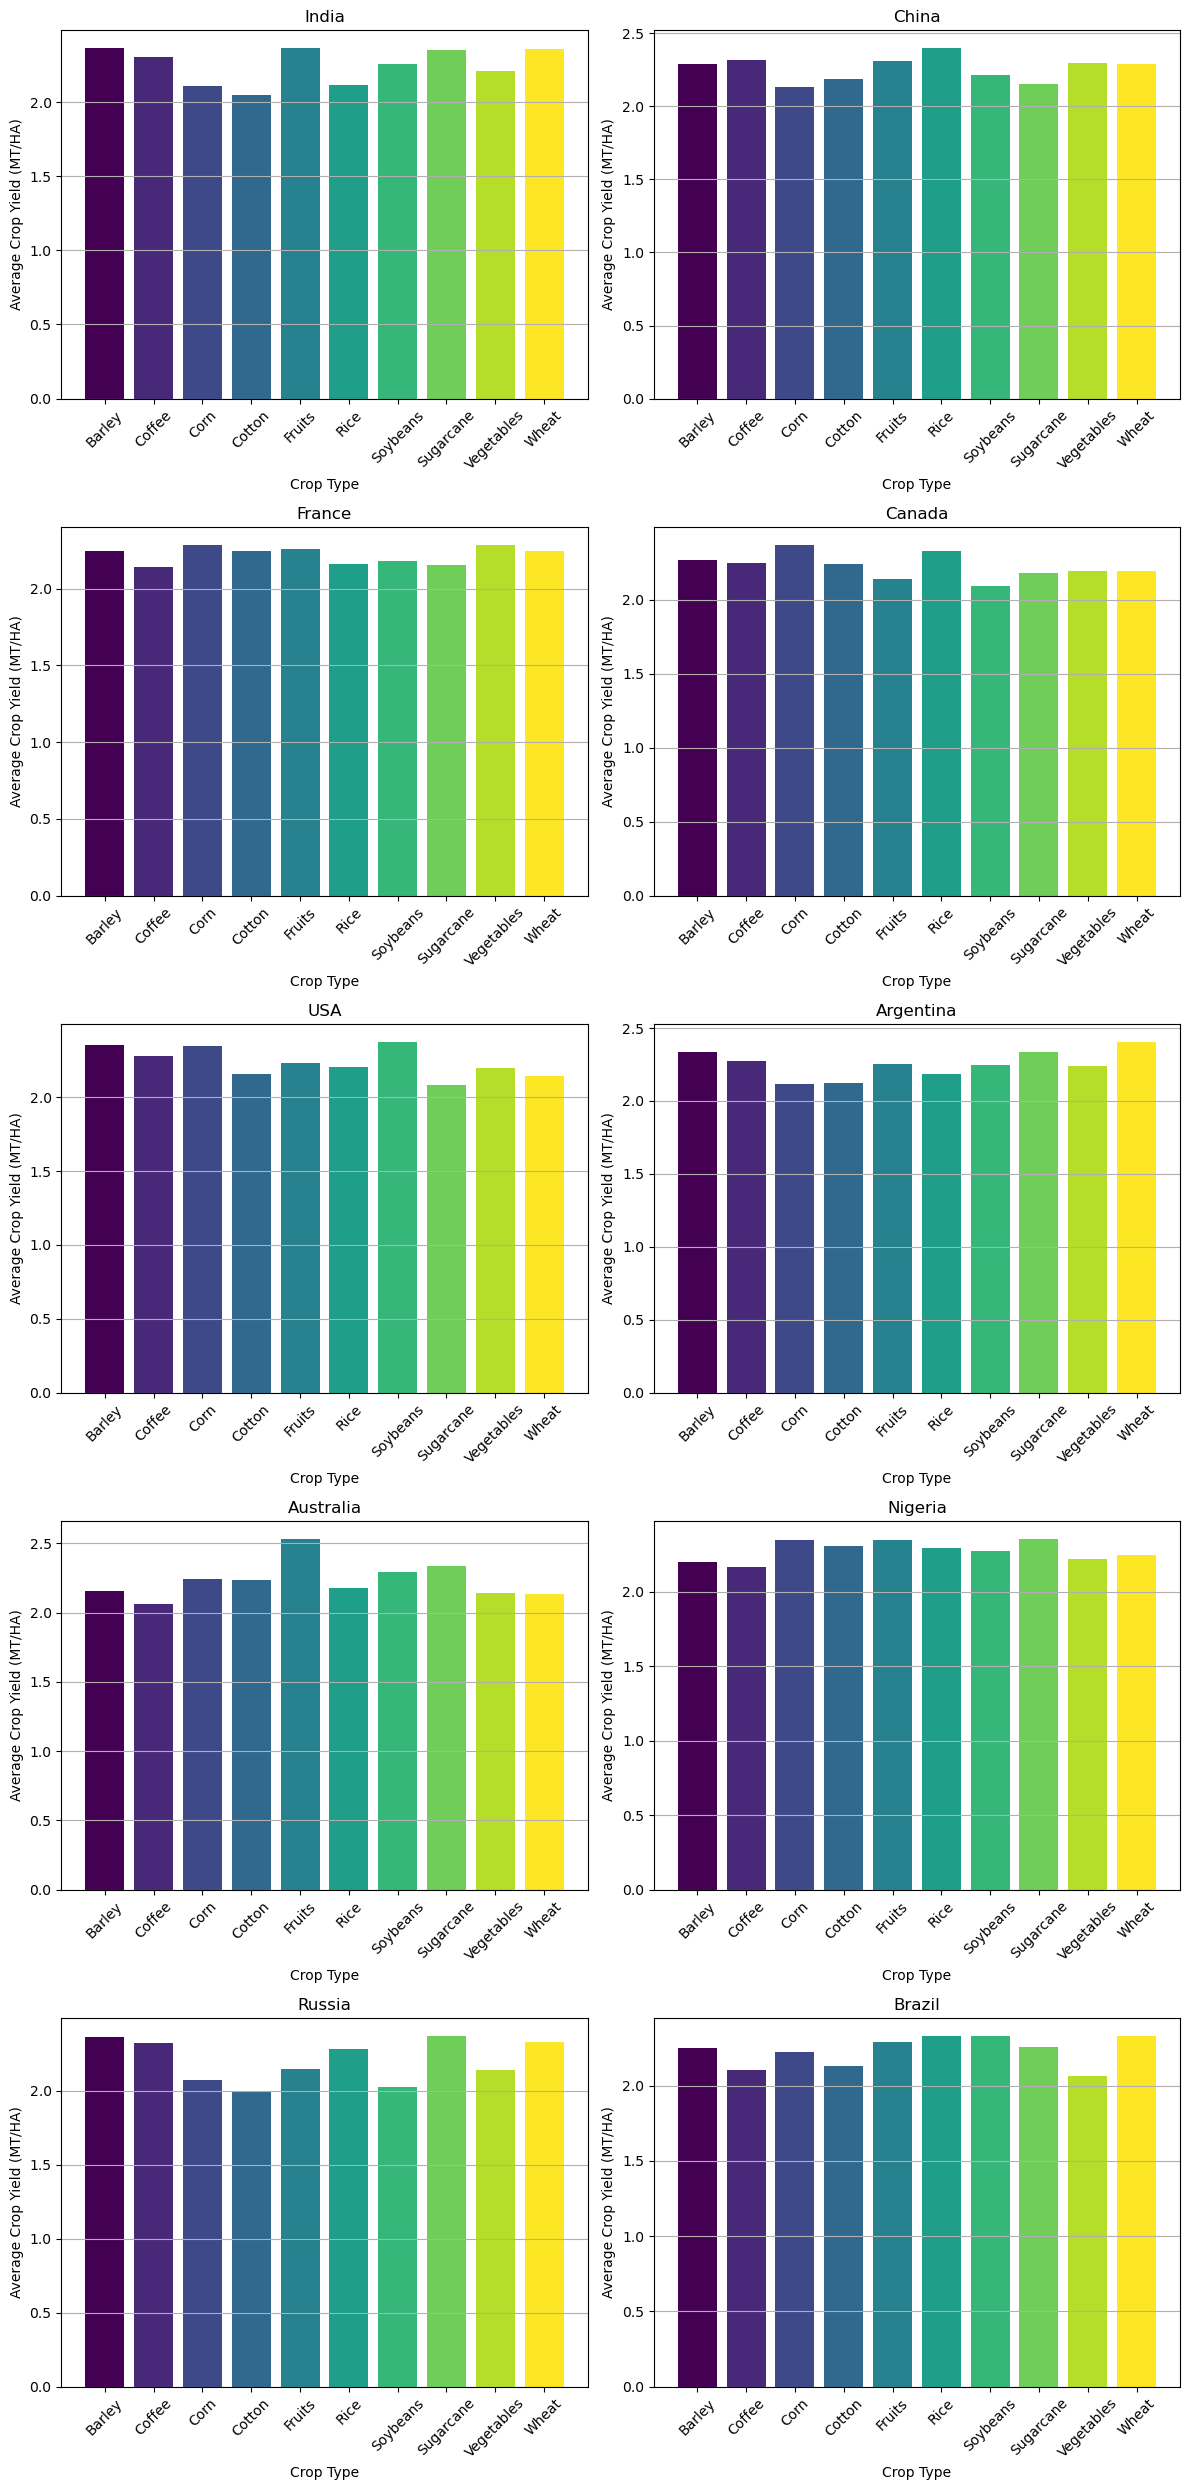

In [63]:
# Yield of each Crop in each Country
countries = df['Country'].unique()

# Calculate number of countries
n_countries = len(countries)

# Create enough rows and columns
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

# Make axes a 1D array
axes = axes.flatten()

for i, country in enumerate(countries):
    df1 = df[df['Country'] == country]

    total = (
        df1.groupby('Crop_Type')['Crop_Yield_MT_per_HA']
        .mean()
        .reset_index()
    )

    axes[i].bar(
        total['Crop_Type'],
        total['Crop_Yield_MT_per_HA'],
        color=colors
    )

    axes[i].set_title(country)
    axes[i].set_xlabel('Crop Type')
    axes[i].set_ylabel('Average Crop Yield (MT/HA)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y')

# Remove unused subplots
for j in range(n_countries, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

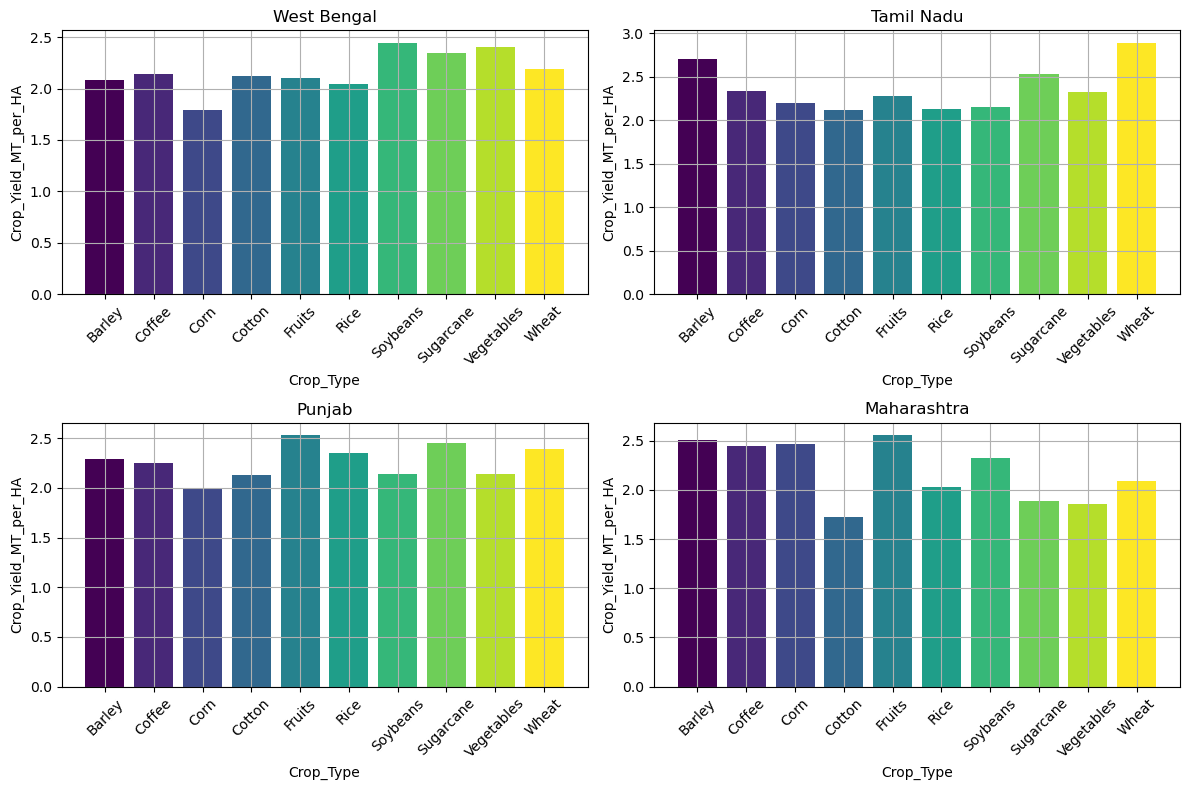

In [58]:
# Yield Crop In diff Region of India
df1 = df[df['Country']== 'India']
region = df1['Region'].unique()

fig, axes = plt.subplots(2,2, figsize=(12, 8))
axes = axes.flatten()
for i, re in enumerate (region):
    df2 = df1[df1['Region']== re]
    total = df2.groupby('Crop_Type')['Crop_Yield_MT_per_HA'].mean().reset_index()
    axes[i].bar(total['Crop_Type'], total['Crop_Yield_MT_per_HA'], color=colors)
    axes[i].set_title(re)
    axes[i].set_xlabel('Crop_Type')
    axes[i].set_ylabel('Crop_Yield_MT_per_HA')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


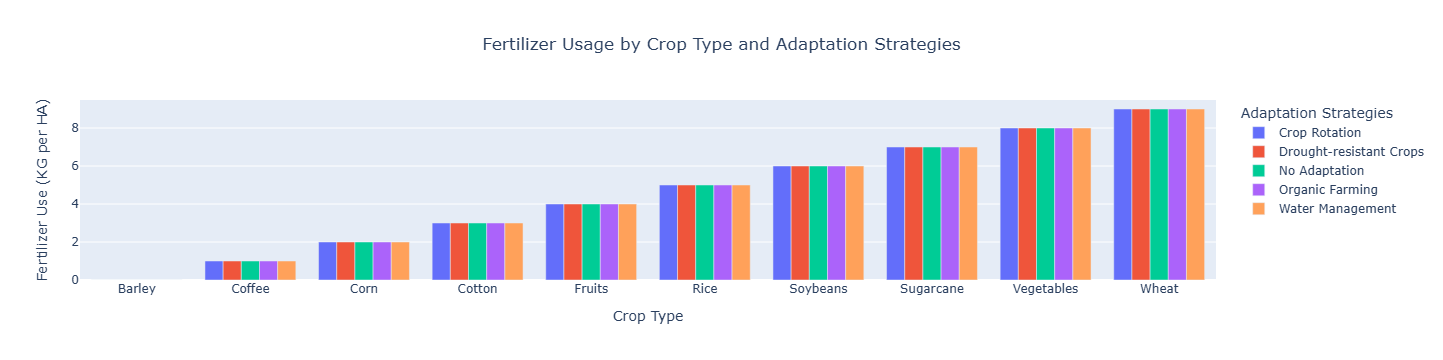

In [59]:
import plotly.express as px

# Reshape the data into a long format suitable for Plotly
fertilizer_usage = df.groupby(['Crop_Type', 'Adaptation_Strategies'])['Fertilizer_Use_KG_per_HA'].sum().reset_index()

# Create the stacked bar chart
fig = px.bar(fertilizer_usage,
            x='Crop_Type',
            y='Fertilizer_Use_KG_per_HA',
            color='Adaptation_Strategies',
            title='Fertilizer Usage by Crop Type and Adaptation Strategies')

# Update layout for better visualization
fig.update_layout(
    xaxis_title="Crop Type",
    yaxis_title="Fertilizer Use (KG per HA)",
    legend_title="Adaptation Strategies",
    barmode="group",
    title_x=0.5
)
# Show the plot
fig.show()

In [60]:
total_yeild = df.groupby(['Country','Crop_Type'])['Crop_Yield_MT_per_HA'].sum().reset_index()
total_yeild.head()

,Country,Crop_Type,Crop_Yield_MT_per_HA
0,Argentina,Barley,210.513
1,Argentina,Coffee,190.988
2,Argentina,Corn,226.738
3,Argentina,Cotton,191.021
4,Argentina,Fruits,245.337


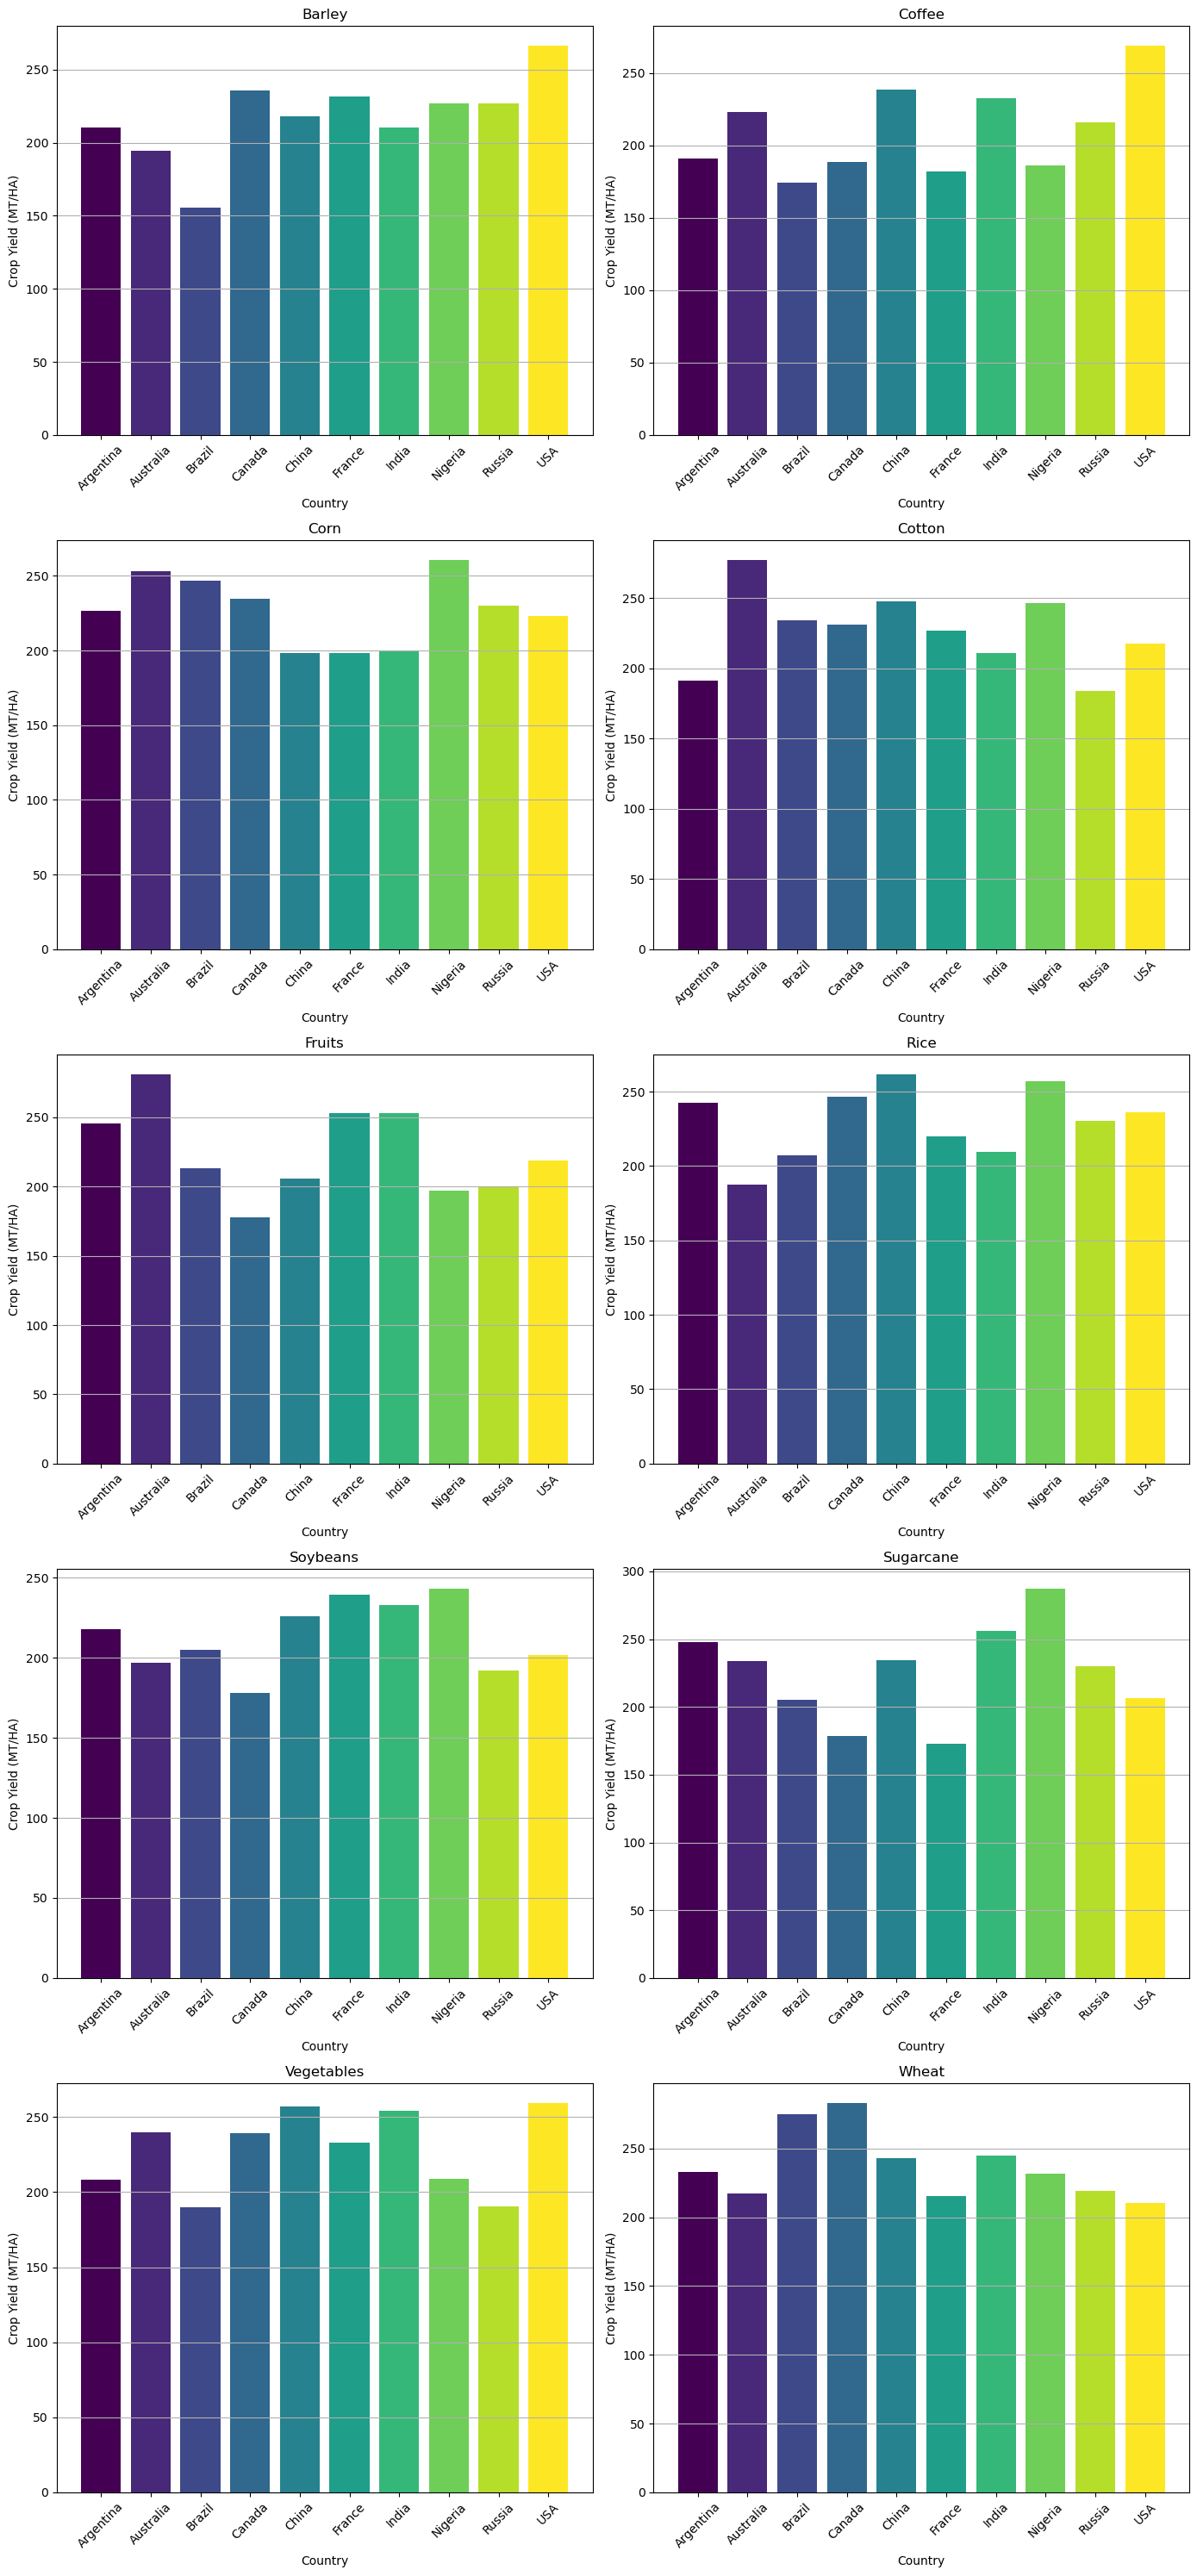

In [64]:
# Yield of each Crop in each Country

crops = total_yeild['Crop_Type'].unique()

# Number of crops
n_crops = len(crops)

# Set number of columns
n_cols = 2

# Calculate required number of rows
n_rows = (n_crops + n_cols - 1) // n_cols

# Create subplots dynamically
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 6 * n_rows)
)

# Convert axes to 1D array
axes = axes.flatten()

for i, crop in enumerate(crops):

    df3 = total_yeild[total_yeild['Crop_Type'] == crop]

    total = (
        df3.groupby('Country')['Crop_Yield_MT_per_HA']
        .sum()
        .reset_index()
    )

    axes[i].bar(
        total['Country'],
        total['Crop_Yield_MT_per_HA'],
        color=colors
    )

    axes[i].set_title(crop)
    axes[i].set_xlabel('Country')
    axes[i].set_ylabel('Crop Yield (MT/HA)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y')

# Remove unused subplots
for j in range(n_crops, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

""""
The analysis demonstrates comprehensive coverage of environmental, adaptation and economic factors, while correlation analysis provides an important analytical tool for identifying the direction and strength of relationships between these variables and crop yield. By revealing patterns and associations within the data, correlation helps analysts identify potentially influential factors, detect relationships that require further investigation, and support evidence-based decision-making. It is also useful in machine learning because it can assist with feature selection and provide an initial understanding of which variables may contain useful information for predicting the target variable.In this study, examining relationships between crop yield, temperature, precipitation, extreme weather events and agricultural inputs provides a useful basis for understanding patterns associated with agricultural productivity and climate-related impacts. However, correlation does not establish cause and effect, meaning that further statistical analysis is required to determine whether identified relationships represent causal influences.

"""